In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pymysql
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [ ]:
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)


In [109]:
df = pd.read_sql("select * from vendor_sales_summary",engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Grossprofit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320.0,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,0.255408,0.959375,1.343018
1,4466,AMERICAN VINTAGE BEVERAGE,5255,TGI Fridays Ultimte Mudslide,9.35,12.99,1750.0,6215.0,58110.25,6096.0,79187.04,51180.60,11204.28,793.91,21076.79,0.266165,0.980853,1.362703
2,4466,AMERICAN VINTAGE BEVERAGE,5215,TGI Fridays Long Island Iced,9.41,12.99,1750.0,4923.0,46325.43,4651.0,60416.49,41542.02,8548.96,793.91,14091.06,0.233232,0.944749,1.304175
3,480,BACARDI USA INC,3348,Bombay Sapphire Gin,22.38,29.99,1750.0,57349.0,1283470.62,56888.0,1766391.12,460087.95,104524.54,89286.27,482920.50,0.273394,0.991961,1.376261
4,480,BACARDI USA INC,8358,Bacardi 151 Proof,14.49,19.99,750.0,7071.0,102458.79,8065.0,161219.35,87396.28,6352.66,89286.27,58760.56,0.364476,1.140574,1.573504


Exploratory Data Analysis

Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [ ]:
df.describe().T

In [ ]:
# Distribution Plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Distribution Plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

Summary Statistics Insights:

Negative & Zero Values:

Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:

Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

In [ ]:
# let's filter the data by removing inconsistencies

df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0
""", engine)

In [ ]:
df

In [ ]:
# Distribution Plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]  # Top 10 categories
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

extract the correlation insights

Correlation Insights

PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

There is a strong correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.999), confirming efficient inventory turnover.
    
ProfitMargin has a negative correlation with TotalSalesPrice (-0.179), suggesting that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
    
StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

Data Analysis

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [ ]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [ ]:
brand_performance

In [ ]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)

high_margin_threshold = (brand_performance['ProfitMargin'].quantile(0.85))

In [ ]:
low_sales_threshold

In [ ]:
high_margin_threshold

In [ ]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

In [ ]:
brand_performance =brand_performance[brand_performance['TotalSalesDollars']<10000]

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="blue",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"${value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"${value / 1_000:.2f}K"
    else:
        return str(value)

In [ ]:
# Top Vendors & Brands by Sales Performance

top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors

In [ ]:
top_brands.apply(lambda x : format_dollars(x))


In [ ]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

In [ ]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'Grossprofit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()



In [ ]:
vendor_performance['Purchase_Contribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()
)

In [ ]:
vendor_performance=round(vendor_performance.sort_values('Purchase_Contribution%',ascending = False),2)*100
vendor_performance

In [ ]:
# Display Top 10 Vendors

top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['Grossprofit'] = top_vendors['Grossprofit'].apply(format_dollars)

top_vendors

In [ ]:
top_vendors['Purchase_Contribution%'].sum()

In [ ]:
top_vendors['Cumulative_Contribution'] = top_vendors['Purchase_Contribution%'].cumsum()
top_vendors

In [118]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'Grossprofit',
       'ProfitMargin', 'StockTurnover', 'SalestoPurchaseRatio', 'Unit_price'],
      dtype='object')

Does purchaisng in bulk reduce the unit price ,and what is the optimal purchase volumne for cost saving?

In [146]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [128]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Grossprofit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,Unit_price,OrderSize
0,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320.0,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,0.255408,0.959375,1.343018,35.71,Medium
1,4466,AMERICAN VINTAGE BEVERAGE,5255,TGI Fridays Ultimte Mudslide,9.35,12.99,1750.0,6215.0,58110.25,6096.0,79187.04,51180.60,11204.28,793.91,21076.79,0.266165,0.980853,1.362703,9.35,Large
2,4466,AMERICAN VINTAGE BEVERAGE,5215,TGI Fridays Long Island Iced,9.41,12.99,1750.0,4923.0,46325.43,4651.0,60416.49,41542.02,8548.96,793.91,14091.06,0.233232,0.944749,1.304175,9.41,Large
3,480,BACARDI USA INC,3348,Bombay Sapphire Gin,22.38,29.99,1750.0,57349.0,1283470.62,56888.0,1766391.12,460087.95,104524.54,89286.27,482920.50,0.273394,0.991961,1.376261,22.38,Large
4,480,BACARDI USA INC,8358,Bacardi 151 Proof,14.49,19.99,750.0,7071.0,102458.79,8065.0,161219.35,87396.28,6352.66,89286.27,58760.56,0.364476,1.140574,1.573504,14.49,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,4425,MARTIGNETTI COMPANIES,28007,Priest Ranch Sauvignon Blanc,12.41,18.99,750.0,120.0,1489.20,0.0,0.00,0.00,0.00,144929.24,-1489.20,0.000000,0.000000,0.000000,12.41,Medium
10688,7153,PINE STATE TRADING CO,26508,Ch Maycott Red,6.81,10.49,750.0,1.0,6.81,1.0,10.49,10.49,0.11,15884.82,3.68,0.350810,1.000000,1.540382,6.81,Small
10689,8004,SAZERAC CO INC,2936,Abraham Bowman Ltd Edition,53.02,69.99,750.0,18.0,954.36,4.0,279.96,69.99,3.15,50293.62,-674.40,-2.408916,0.222222,0.293348,53.02,Small
10690,2000,SOUTHERN WINE & SPIRITS NE,26266,The Divining Rod Pinot Noir,11.56,16.99,750.0,132.0,1525.92,2.0,33.98,16.99,0.22,19016.59,-1491.94,-43.906416,0.015152,0.022269,11.56,Medium


In [124]:
df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"]
)



In [142]:
df[["OrderSize", "TotalPurchaseQuantity"]].sort_values(
    by="TotalPurchaseQuantity")

,OrderSize,TotalPurchaseQuantity
9503,Small,1.0
6152,Small,1.0
6151,Small,1.0
9709,Small,1.0
4459,Small,1.0
...,...,...
1110,Large,215668.0
495,Large,226085.0
1683,Large,244654.0
434,Large,254824.0


In [148]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


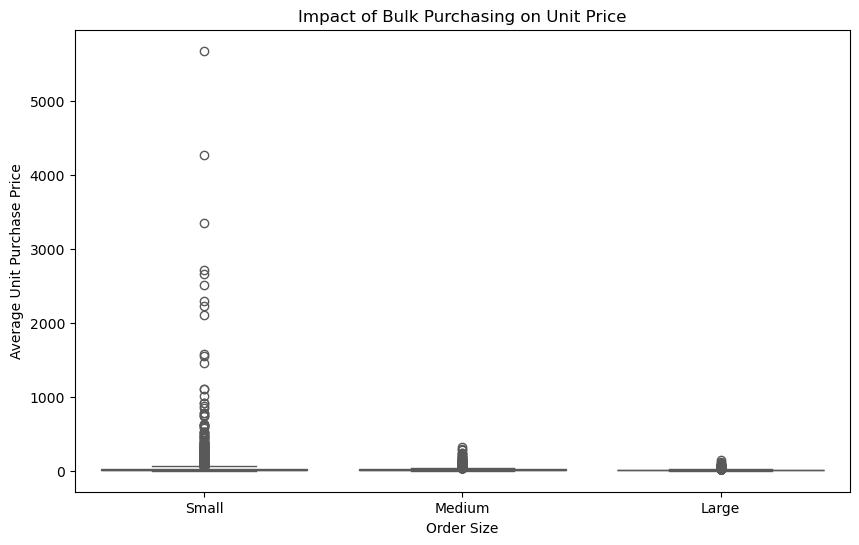

In [150]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
    
The price difference between Small and Large orders is substantial (~72% reduction in unit cost).
                                                                    
This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [187]:
df['StockTurnover'][df['StockTurnover']<1].sort_values(ascending = False)

8393     0.999959
887      0.999900
9029     0.999821
9902     0.999818
407      0.999801
           ...   
6984     0.000000
6964     0.000000
6945     0.000000
6905     0.000000
10691    0.000000
Name: StockTurnover, Length: 6334, dtype: float64

In [165]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
UNCORKED,0.217238
MILTONS DISTRIBUTING CO,0.236111
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333


how much capital is locked in unsold inventry per endor and which vendors contribute the most of it ?

In [190]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]

print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)

inventory_value_per_vendor.head(10)

Total Unsold Capital: $8.75M


,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,$980.09K
63,MARTIGNETTI COMPANIES,$926.08K
50,JIM BEAM BRANDS COMPANY,$857.80K
115,ULTRA BEVERAGE COMPANY LLP,$780.27K
74,PERFECTA WINES,$571.81K
75,PERNOD RICARD USA,$554.74K
59,M S WALKER INC,$469.96K
126,WILLIAM GRANT & SONS INC,$436.49K
33,E & J GALLO WINERY,$315.20K
14,BROWN-FORMAN CORP,$284.91K
